In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("urban_surface.csv")

df['neighbourhood_id'].nunique()
len(df)

500

In [7]:
df.describe()

,neighbourhood_id,latitude,longitude,distance_from_center_km,tree_cover_pct,asphalt_pct,building_density,median_income,population_density,heat_retention_factor,infrastructure_quality_index,social_vulnerability_index
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,250.500000,22.307747,73.183746,10.792948,28.972086,76.073890,0.455005,8.562014e+05,9564.111070,1.000872,1.005118,0.988338
std,144.481833,0.078500,0.078240,5.891577,15.820085,14.695388,0.171689,3.399482e+05,5150.457633,0.115843,0.287382,0.406478
min,1.000000,22.047899,72.965449,0.259466,5.000000,33.306247,0.300000,2.000000e+05,2000.000000,0.801976,0.503218,0.300189
25%,125.750000,22.251175,73.133577,6.491979,15.991478,65.081315,0.300000,6.313902e+05,5146.365440,0.895508,0.755995,0.677418
50%,250.500000,22.308224,73.183483,10.036926,29.790432,79.462835,0.387656,8.715711e+05,9732.217185,1.004329,1.018732,0.972176
75%,375.250000,22.358143,73.233299,14.429001,40.818177,90.000000,0.577494,1.112554e+06,13808.254022,1.094608,1.255469,1.339555
max,500.000000,22.615419,73.391791,37.382062,70.000000,90.000000,0.942373,1.660896e+06,22204.322610,1.199765,1.498348,1.696949


In [8]:
df.isnull().sum()

neighbourhood_id                0
latitude                        0
longitude                       0
distance_from_center_km         0
tree_cover_pct                  0
asphalt_pct                     0
building_density                0
median_income                   0
population_density              0
heat_retention_factor           0
infrastructure_quality_index    0
social_vulnerability_index      0
dtype: int64

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[['tree_cover_pct','asphalt_pct','building_density',
        'population_density','heat_retention_factor']]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif) #If VIF > 10 for some variables, they are overlapping heavily

                Variable         VIF
0                  const  655.750212
1         tree_cover_pct    8.169613
2            asphalt_pct    9.805666
3       building_density    9.013043
4     population_density    8.763495
5  heat_retention_factor    1.003317


In [14]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,neighbourhood_id,latitude,longitude,distance_from_center_km,tree_cover_pct,asphalt_pct,building_density,median_income,population_density,heat_retention_factor,infrastructure_quality_index,social_vulnerability_index
neighbourhood_id,1.000000,0.021805,0.076006,0.031634,-0.036406,0.023939,-0.027613,-0.019384,-0.023088,-0.033668,-0.002459,0.013063
latitude,0.021805,1.000000,-0.075671,0.057316,-0.050617,0.023620,-0.009382,-0.042582,-0.037877,0.026332,-0.061734,0.017317
longitude,0.076006,-0.075671,1.000000,0.068851,-0.057917,0.030709,-0.033386,-0.045780,-0.046690,0.023794,0.021153,-0.036698
distance_from_center_km,0.031634,0.057316,0.068851,1.000000,-0.925202,0.845309,-0.837494,-0.941243,-0.925733,0.045770,-0.062466,-0.039526
tree_cover_pct,-0.036406,-0.050617,-0.057917,-0.925202,1.000000,-0.880935,0.869148,0.916005,0.927705,-0.017614,0.075203,0.044181
asphalt_pct,0.023939,0.023620,0.030709,0.845309,-0.880935,1.000000,-0.936273,-0.852181,-0.886436,-0.002626,-0.108190,0.017014
building_density,-0.027613,-0.009382,-0.033386,-0.837494,0.869148,-0.936273,1.000000,0.848904,0.879746,-0.008088,0.086469,0.009593
median_income,-0.019384,-0.042582,-0.045780,-0.941243,0.916005,-0.852181,0.848904,1.000000,0.917315,-0.042796,0.080904,0.033047
population_density,-0.023088,-0.037877,-0.046690,-0.925733,0.927705,-0.886436,0.879746,0.917315,1.000000,-0.023372,0.104607,0.044468
heat_retention_factor,-0.033668,0.026332,0.023794,0.045770,-0.017614,-0.002626,-0.008088,-0.042796,-0.023372,1.000000,-0.025211,-0.003501


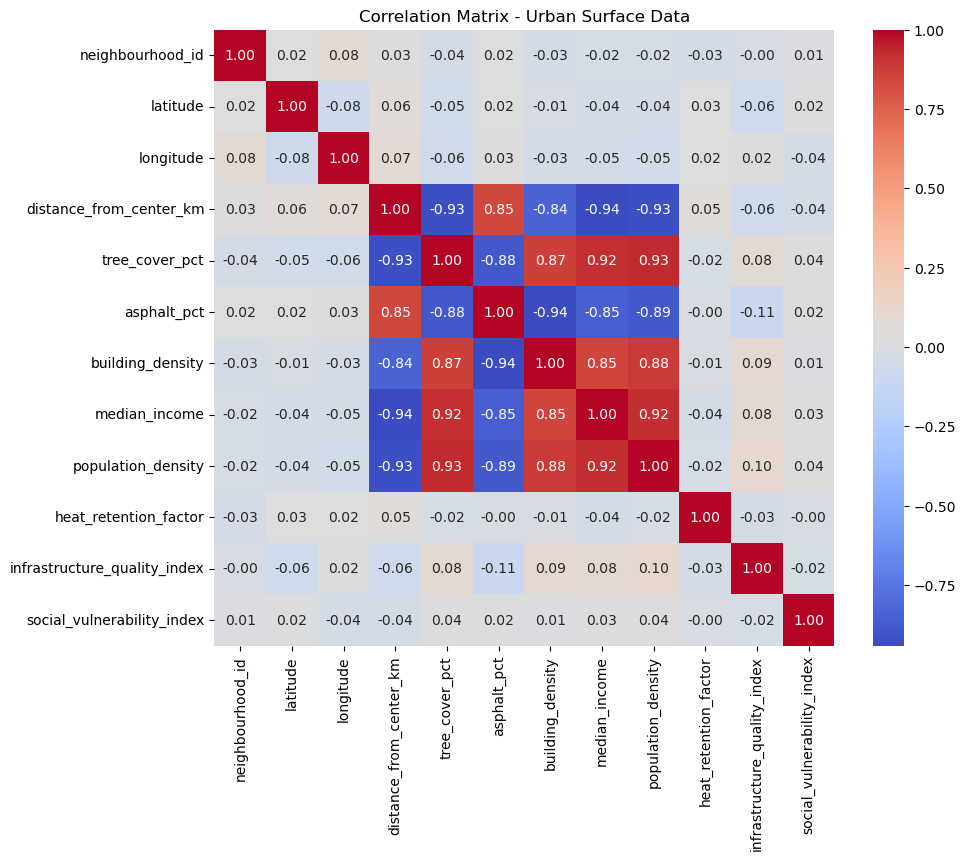

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Urban Surface Data")
plt.show() 
#Red → strong positive
#Blue → strong negative
#White → weakWhite → weak
#As you move away from city center, tree cover increases.
#Asphalt and building density behave inversely with greenery.
#Strongest Positive Correlations

#tree_cover_pct vs population_density ≈ 0.93
#tree_cover_pct vs median_income ≈ 0.92
#median_income vs population_density ≈ 0.92
#building_density vs population_density ≈ 0.88

In [16]:
corr_matrix.unstack().sort_values(ascending=False)
#Above 0.6 → strong positive
#Below -0.6 → strong negative

neighbourhood_id              neighbourhood_id                1.000000
latitude                      latitude                        1.000000
infrastructure_quality_index  infrastructure_quality_index    1.000000
heat_retention_factor         heat_retention_factor           1.000000
population_density            population_density              1.000000
                                                                ...   
                              distance_from_center_km        -0.925733
asphalt_pct                   building_density               -0.936273
building_density              asphalt_pct                    -0.936273
median_income                 distance_from_center_km        -0.941243
distance_from_center_km       median_income                  -0.941243
Length: 144, dtype: float64

In [20]:
df.to_csv("urban_surface_clean.csv", index=False)